In [1]:
import pandas as pd
import numpy as np
import os
import torch
import matplotlib.pyplot as plt

C:\Users\MacRaeDC\AppData\Local\Temp\ipykernel_30924\1149221576.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was too old on your system - pyarrow 10.0.1 is the current minimum supported version as of this release.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
predictions_path = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/Users/Daniel MacRae/DL_NTCP_Multitox/HP_experiments/EarlyStopping/HP_ResNet_MeanLoss/66afd5c4/20240402_045444_5_805_21_resnet_lrelu_params_310013_auc_tr_0.806_val_0.725/resnet_lrelu_all_outputs.csv"

df_preds = pd.read_csv(predictions_path, delimiter=";")




In [3]:
df_val_preds = df_preds[df_preds["Mode"] == "val"]
xero_preds = df_val_preds.Xerostomia_M06_pred.to_numpy()
xero_labels = df_val_preds.Xerostomia_M06_true.to_numpy()

sticky_preds = df_val_preds.Sticky_M06_pred.to_numpy()
sticky_labels = df_val_preds.Sticky_M06_true.to_numpy()

In [4]:
preds = torch.tensor(xero_preds)
true = torch.tensor(xero_labels)

preds = torch.tensor(sticky_preds)
true = torch.tensor(sticky_labels)

In [5]:
from torchmetrics.classification import BinaryCalibrationError


metric = BinaryCalibrationError(n_bins=10, norm='l1')



mask = (true == 0) | (true == 1)
preds = preds[mask]
true = true[mask]


metric(preds, true)

tensor(0.0478, dtype=torch.float64)

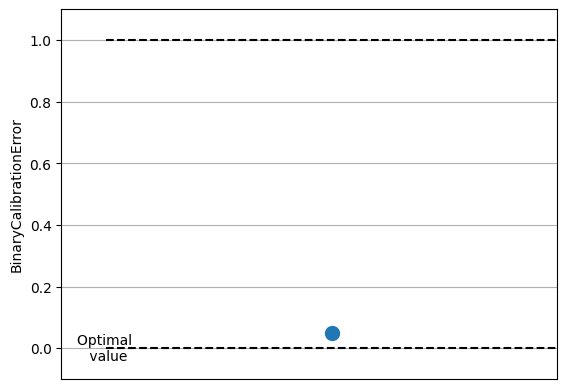

In [6]:
fig_, ax_ = metric.plot()


In [7]:
import numpy as np 
num_bins = 10
a = np.array([0.05, 0.1, 0.15, 0.24]) 
bins = np.linspace(0, 1, num_bins+1)
  
# using np.digitize() method 
gfg = np.digitize(a, bins, right=False) 
  
print(gfg)

[1 2 2 3]


In [8]:
bins

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

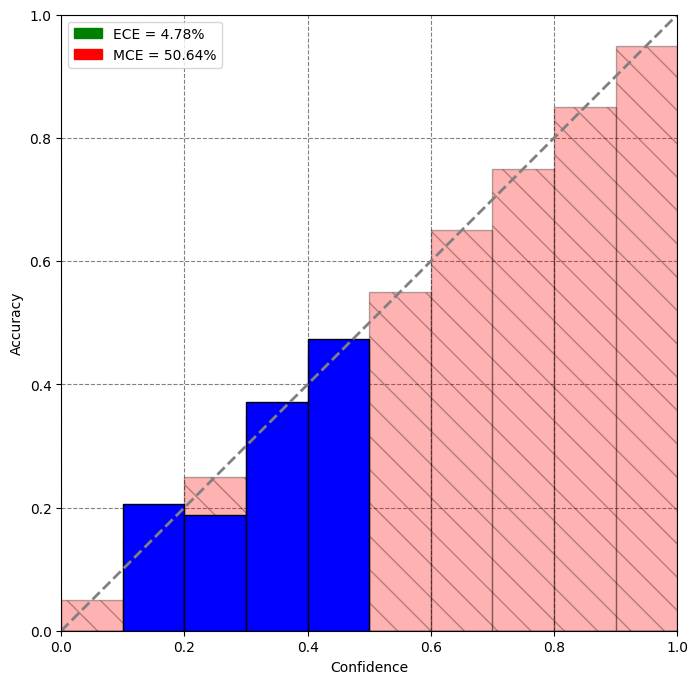

In [9]:

def calc_bins(preds):
  # Assign each prediction to a bin
  num_bins = 10
  bins = np.linspace(0.1, 1, num_bins)
  binned = np.digitize(preds, bins, right=True)
  unique, counts = np.unique(binned, return_counts=True)

  # Save the accuracy, confidence and size of each bin
  bin_accs = np.zeros(num_bins)
  bin_confs = np.zeros(num_bins)
  bin_sizes = np.zeros(num_bins)
  labels_oneh = true
  for bin in range(num_bins):
    bin_sizes[bin] = len(preds[binned == bin])
    if bin_sizes[bin] > 0:
      bin_accs[bin] = (labels_oneh[binned==bin]).sum() / bin_sizes[bin]
      bin_confs[bin] = (preds[binned==bin]).sum() / bin_sizes[bin]

  return bins, binned, bin_accs, bin_confs, bin_sizes


def get_metrics(preds):
  ECE = 0
  MCE = 0
  bins, _, bin_accs, bin_confs, bin_sizes = calc_bins(preds)

  for i in range(len(bins)):
    abs_conf_dif = abs(bin_accs[i] - bin_confs[i])
    ECE += (bin_sizes[i] / sum(bin_sizes)) * abs_conf_dif
    MCE = max(MCE, abs_conf_dif)

  return ECE, MCE


import matplotlib.patches as mpatches

def draw_reliability_graph(preds):
  ECE, MCE = get_metrics(preds)
  bins, _, bin_accs, _, _ = calc_bins(preds)

  fig = plt.figure(figsize=(8, 8))
  ax = fig.gca()

  # x/y limits
  ax.set_xlim(0, 1.05)
  ax.set_ylim(0, 1)

  # x/y labels
  plt.xlabel('Confidence')
  plt.ylabel('Accuracy')

  # Create grid
  ax.set_axisbelow(True) 
  ax.grid(color='gray', linestyle='dashed')

  # Error bars
  plt.bar(bins-0.05, bins-0.05,  width=0.1, alpha=0.3, edgecolor='black', color='r', hatch='\\')

  # Draw bars and identity line
  plt.bar(bins-0.05, bin_accs, width=0.1, alpha=1, edgecolor='black', color='b')
  plt.plot([0,1],[0,1], '--', color='gray', linewidth=2)

  # Equally spaced axes
  plt.gca().set_aspect('equal', adjustable='box')
  plt.xlim([0, 1])

  # ECE and MCE legend
  ECE_patch = mpatches.Patch(color='green', label='ECE = {:.2f}%'.format(ECE*100))
  MCE_patch = mpatches.Patch(color='red', label='MCE = {:.2f}%'.format(MCE*100))
  plt.legend(handles=[ECE_patch, MCE_patch])

  plt.show()
  
  #plt.savefig('calibrated_network.png', bbox_inches='tight')

#draw_reliability_graph(preds)
draw_reliability_graph(preds)


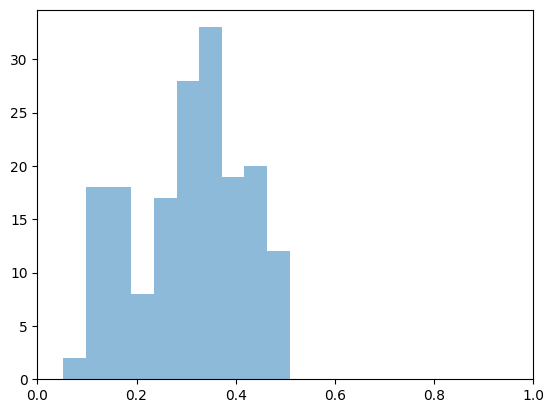

In [10]:
plt.hist(preds, bins=10, alpha=0.5, label='preds')
plt.xlim(0, 1)
plt.show()

In [101]:
preds.min()

tensor(0.0045, dtype=torch.float64)

In [102]:
fig_.show()

C:\Users\MacRaeDC\AppData\Local\Temp\ipykernel_26664\392901088.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_.show()


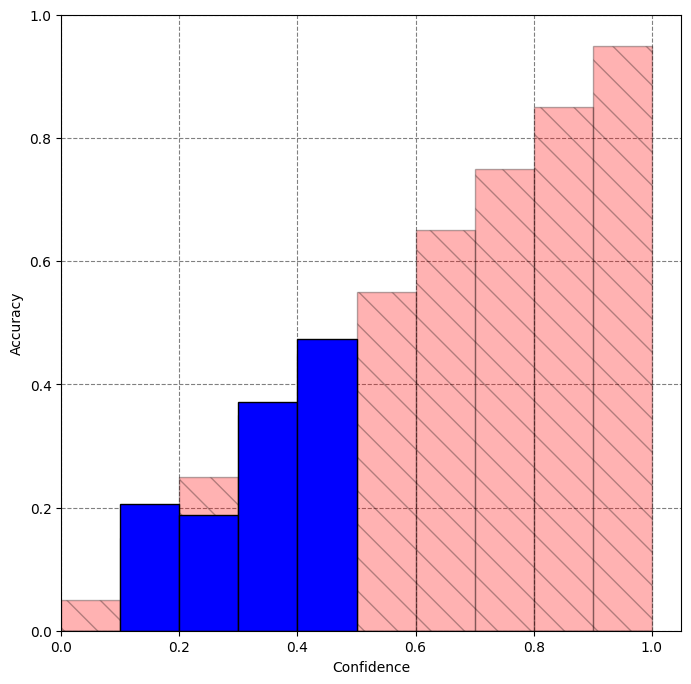

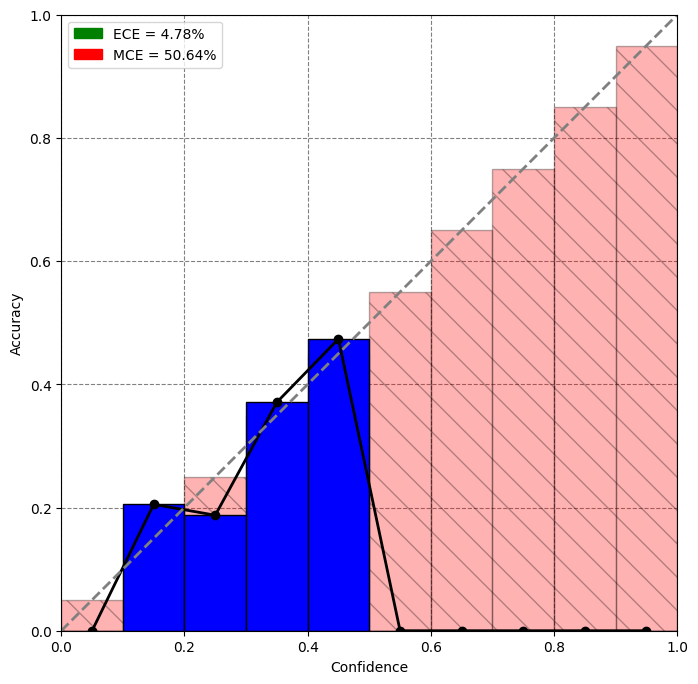

In [18]:


def calc_bins(preds, num_bins):
    # Assign each prediction to a bin

    bins = np.linspace(0.1, 1, num_bins)
    binned = np.digitize(preds, bins, right=True)
    unique, counts = np.unique(binned, return_counts=True)

    # Save the accuracy, confidence and size of each bin
    bin_accs = np.zeros(num_bins)
    bin_confs = np.zeros(num_bins)
    bin_sizes = np.zeros(num_bins)
    labels_oneh = true
    for bin in range(num_bins):
        bin_sizes[bin] = len(preds[binned == bin])
        if bin_sizes[bin] > 0:
            bin_accs[bin] = (labels_oneh[binned==bin]).sum() / bin_sizes[bin]
            bin_confs[bin] = (preds[binned==bin]).sum() / bin_sizes[bin]

    return bins, binned, bin_accs, bin_confs, bin_sizes


def get_ECE_metrics(bins, bin_accs, bin_confs, bin_sizes):
    ECE = 0
    MCE = 0

    for i in range(len(bins)):
        abs_conf_dif = abs(bin_accs[i] - bin_confs[i])
        ECE += (bin_sizes[i] / sum(bin_sizes)) * abs_conf_dif
        MCE = max(MCE, abs_conf_dif)

    return ECE, MCE


import matplotlib.patches as mpatches

def draw_reliability_graph(preds, num_bins=10):
    bins, binned, bin_accs, bin_confs, bin_sizes = calc_bins(preds, num_bins)

    ECE, MCE = get_ECE_metrics(bins, bin_accs, bin_confs, bin_sizes)
    #bins, _, bin_accs, _, _ = calc_bins(preds)

    fig = plt.figure(figsize=(8, 8))
    ax = fig.gca()

    # x/y limits
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1)

    # x/y labels
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')

    # Create grid
    ax.set_axisbelow(True) 
    ax.grid(color='gray', linestyle='dashed')

    # Error bars
    plt.bar(bins-0.05, bins-0.05,  width=0.1, alpha=0.3, edgecolor='black', color='r', hatch='\\')

    # Draw bars and identity line
    plt.bar(bins-0.05, bin_accs, width=0.1, alpha=1, edgecolor='black', color='b')
    plt.plot(bins-0.05, bin_accs, 'o-', color='black', linewidth=2)
    plt.plot([0,1],[0,1], '--', color='gray', linewidth=2)

    # Equally spaced axes
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlim([0, 1])

    # ECE and MCE legend
    ECE_patch = mpatches.Patch(color='green', label='ECE = {:.2f}%'.format(ECE*100))
    MCE_patch = mpatches.Patch(color='red', label='MCE = {:.2f}%'.format(MCE*100))
    plt.legend(handles=[ECE_patch, MCE_patch])

    plt.show()

    #plt.savefig('calibrated_network.png', bbox_inches='tight')

#draw_reliability_graph(preds)
draw_reliability_graph(preds, num_bins=10)
